In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder

# 학습 모델 성능 관련 #######################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습 곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 모델 성능 평가 ########################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 #########################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습 모델 ########################
# 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier 
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier

# 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge
from catboost import CatBoostRegressor

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 차원 축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

# 연관 규칙 학습
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 군집
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth

# 파이프라인
from sklearn.pipeline import Pipeline

# KDE를 그리기 위한 통계값을 구할 수 있는 함수
from scipy.stats import gaussian_kde

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### 데이터를 불러온다.

In [2]:
train_df = pd.read_csv('data/titanic_train2.csv')
test_df = pd.read_csv('data/titanic_test2.csv')

In [3]:
train_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,isChild,FamilySize,FamilySizeGroup
0,0,3,male,22.0,1,0,2.110213,S,Mr,0.0,1,1
1,1,1,female,38.0,1,0,4.280593,C,Mrs,0.0,1,1
2,1,3,female,26.0,0,0,2.188856,S,Miss,0.0,0,0
3,1,1,female,35.0,1,0,3.990834,S,Mrs,0.0,1,1
4,0,3,male,35.0,0,0,2.202765,S,Mr,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,2.639057,S,Rare,0.0,0,0
887,1,1,female,19.0,0,0,3.433987,S,Miss,0.0,0,0
888,0,3,female,NaN,1,2,3.196630,S,Miss,NaN,3,1
889,1,1,male,26.0,0,0,3.433987,C,Mr,0.0,0,0


In [4]:
test_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,isChild,FamilySize,FamilySizeGroup
0,3,male,34.5,0,0,2.178064,Q,Mr,0.0,0,0
1,3,female,47.0,1,0,2.079442,S,Mrs,0.0,1,1
2,2,male,62.0,0,0,2.369075,Q,Mr,0.0,0,0
3,3,male,27.0,0,0,2.268252,S,Mr,0.0,0,0
4,3,female,22.0,1,1,2.586824,S,Mrs,0.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,2.202765,S,Mr,NaN,0,0
414,1,female,39.0,0,0,4.699571,C,Rare,0.0,0,0
415,3,male,38.5,0,0,2.110213,S,Mr,0.0,0,0
416,3,male,NaN,0,0,2.202765,S,Mr,NaN,0,0


### 결측치 확인

In [5]:
a1 = train_df.isna().sum()
a1[a1 > 0]

Age         177
Embarked      2
isChild     177
dtype: int64

In [6]:
a1 = test_df.isna().sum()
a1[a1 > 0]

Age        86
Fare        1
isChild    86
dtype: int64

In [7]:
# 결측치의 개수를 구한다.
null_count = train_df.isna().sum()
# 결측치 비율을 구한다.
null_percent = 100 * null_count / len(train_df)
null_percent[null_percent > 0]

Age         19.865320
Embarked     0.224467
isChild     19.865320
dtype: float64

In [8]:
null_count = test_df.isna().sum()
null_percent = 100 * null_count / len(test_df)
null_percent[null_percent > 0]

Age        20.574163
Fare        0.239234
isChild    20.574163
dtype: float64

### Age 결측치 처리

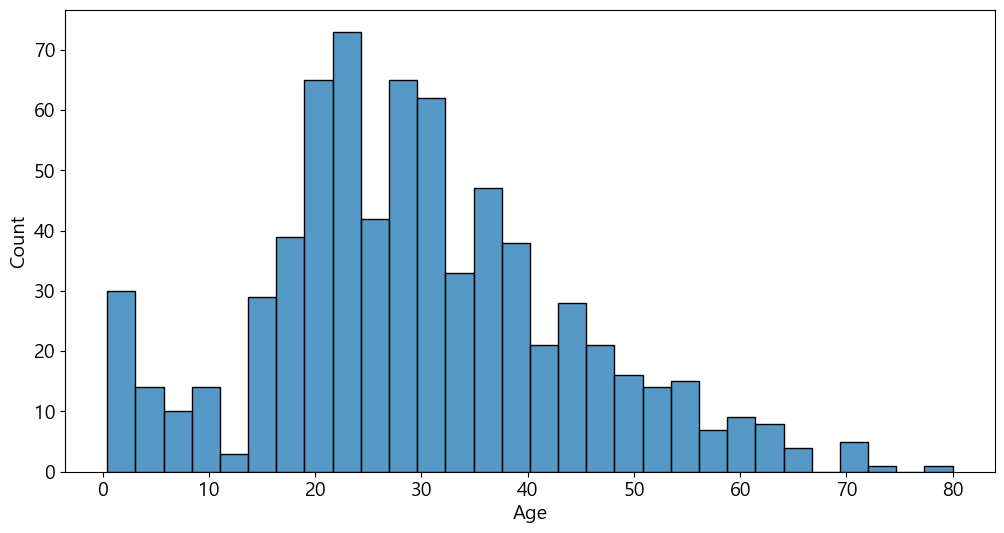

In [9]:
# Age 시각화
sns.histplot(data=train_df['Age'], bins=30)
plt.show()

In [10]:
# Age가 정규분포를 보이지 않기 때문에 중간 값으로 채워준다.
imputer = SimpleImputer(strategy='median')
imputer.fit(train_df[['Age']])

train_df['Age'] = imputer.transform(train_df[['Age']]).flatten()
test_df['Age'] = imputer.transform(test_df[['Age']]).flatten()

In [11]:
print(train_df['Age'].isna().sum())
print(test_df['Age'].isna().sum())

0
0


### Embarked 결측치 처리

In [12]:
# 범주형 데이터 이므로 최빈값으로 설정한다.
imputer = SimpleImputer(strategy='most_frequent')
imputer.fit(train_df[['Embarked']])

train_df['Embarked'] = imputer.transform(train_df[['Embarked']]).flatten()

In [13]:
train_df['Embarked'].isna().sum()

np.int64(0)

### isChild 결측치 처리

In [14]:
# 범주형 데이터 이므로 최빈값으로 채워준다.
imputer = SimpleImputer(strategy='most_frequent')
imputer.fit(train_df[['isChild']])

train_df['isChild'] = imputer.transform(train_df[['isChild']]).flatten()
test_df['isChild'] = imputer.transform(test_df[['isChild']]).flatten()

In [15]:
print(train_df['isChild'].isna().sum())
print(test_df['isChild'].isna().sum())

0
0


### Fare

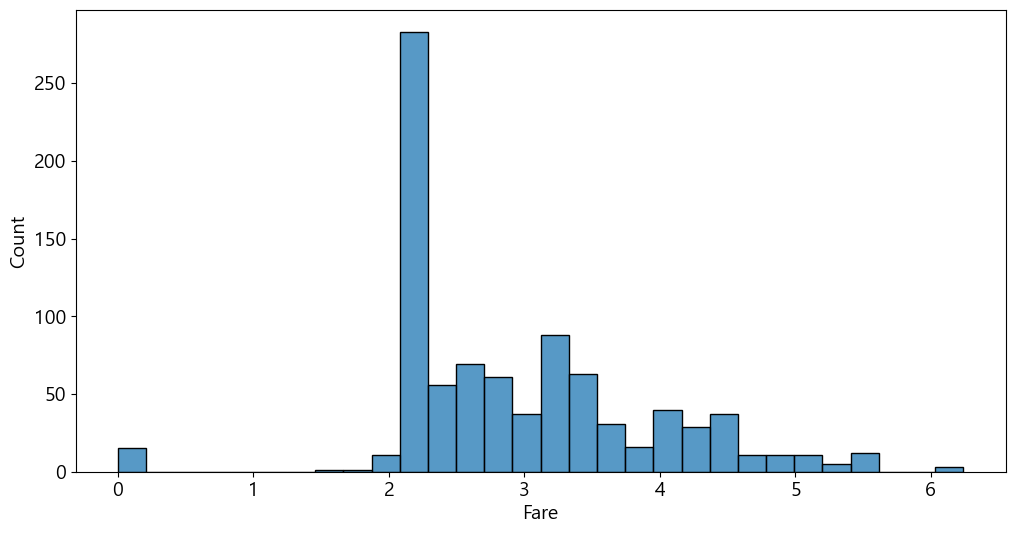

In [16]:
# 연속형 수치형 데이터 이므로 히스토 그램을 확인한다.
sns.histplot(data=train_df, x='Fare', bins=30)
plt.show()

In [17]:
# 평균으로 채워준다.
imputer = SimpleImputer(strategy='mean')
imputer.fit(train_df[['Fare']])

test_df['Fare'] = imputer.transform(test_df[['Fare']]).flatten()

In [18]:
test_df['Fare'].isna().sum()

np.int64(0)

### 전체적으로 확인

In [19]:
train_df.isna().sum()

Survived           0
Pclass             0
Sex                0
Age                0
SibSp              0
Parch              0
Fare               0
Embarked           0
Title              0
isChild            0
FamilySize         0
FamilySizeGroup    0
dtype: int64

In [20]:
test_df.isna().sum()

Pclass             0
Sex                0
Age                0
SibSp              0
Parch              0
Fare               0
Embarked           0
Title              0
isChild            0
FamilySize         0
FamilySizeGroup    0
dtype: int64

In [21]:
# 저장
train_df.to_csv('data/titanic_train3.csv', index=False)
test_df.to_csv('data/titanic_test3.csv', index=False)